In [21]:
import torch

import matplotlib.pyplot as plt

import numpy as np

from PIL import Image

from torchvision import transforms

from torchvision.models import resnet18

import torch.nn as nn

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import show_cam_on_image

from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [22]:
model = resnet18(weights=None)

model.fc = nn.Linear(
    in_features=512,
    out_features=4
)

model.load_state_dict(
    torch.load("../models/resnet18_brain_tumor.pth")
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [23]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [24]:
image_path = r"C:\Users\nagas\OneDrive\Desktop\NeuroVision-AI\data\Testing\pituitary\Te-pi_25.jpg"

original_image = Image.open(image_path).convert("RGB")

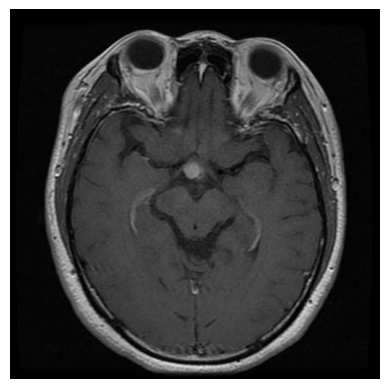

In [25]:
plt.imshow(original_image)
plt.axis("off")
plt.show()

In [26]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

input_tensor = transform(original_image)

input_tensor = input_tensor.unsqueeze(0)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [27]:
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)

print(predicted)

tensor([3])


In [28]:
target_category = predicted.item()

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(target_category)]
)

grayscale_cam = grayscale_cam[0]

RGB image shape: (224, 224, 3)
Grad-CAM shape: (224, 224)


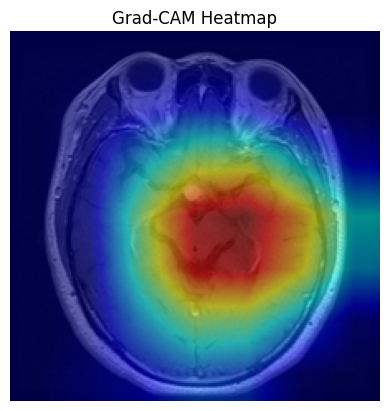

In [30]:
# Resize the original image to the same size used by the model
display_image = original_image.resize((224, 224))

# Convert to a float NumPy array with values between 0 and 1
rgb_image = np.array(display_image, dtype=np.float32) / 255.0

print("RGB image shape:", rgb_image.shape)
print("Grad-CAM shape:", grayscale_cam.shape)

visualization = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

plt.imshow(visualization)
plt.title("Grad-CAM Heatmap")
plt.axis("off")
plt.show()

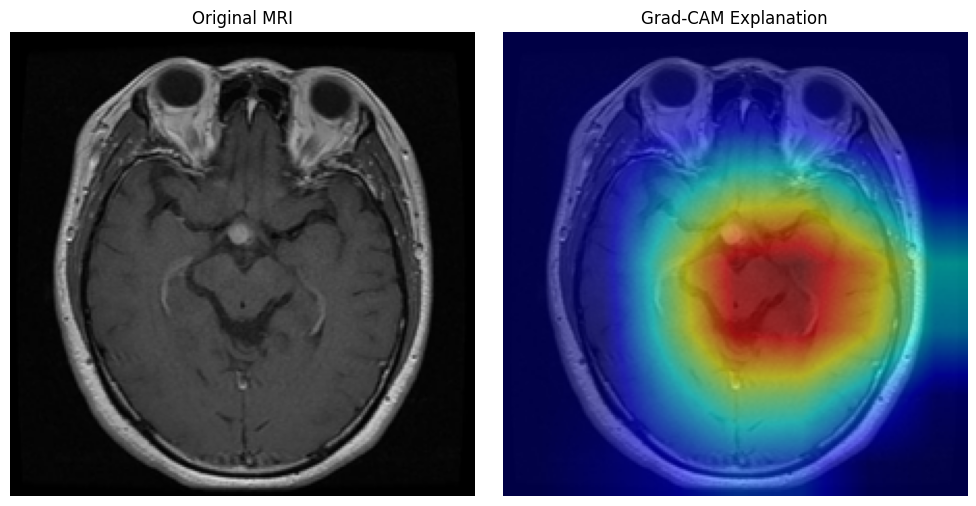

In [31]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(display_image)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.tight_layout()
plt.show()